In [68]:
import pandas as pd

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [69]:
# Create two separate DataFrames to merge
# In real projects these would come from different database tables or CSV files

# Passenger basic info
passengers = df[['PassengerId', 'Name', 'Age', 'Sex']].copy()

# Passenger travel info
travel = df[['PassengerId', 'Pclass', 'Fare', 'Survived']].copy()

print("Passengers shape:", passengers.shape)   # (891, 4)
print("Travel shape:", travel.shape)           # (891, 4)

Passengers shape: (891, 4)
Travel shape: (891, 4)


In [70]:
# Inner join — combine on PassengerId
combined = pd.merge(passengers, travel, on='PassengerId', how='inner')
print(combined.shape)    # (891, 7) — all columns combined
combined.head()

(891, 7)


,PassengerId,Name,Age,Sex,Pclass,Fare,Survived
0,1,"Braund, Mr. Owen Harris",22.0,male,3,7.2500,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,female,1,71.2833,1
2,3,"Heikkinen, Miss. Laina",26.0,female,3,7.9250,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,female,1,53.1000,1
4,5,"Allen, Mr. William Henry",35.0,male,3,8.0500,0


In [71]:
combined['SexEncoded'] = combined.Sex.map({'male': 0, 'female': 1})
combined.head()

,PassengerId,Name,Age,Sex,Pclass,Fare,Survived,SexEncoded
0,1,"Braund, Mr. Owen Harris",22.0,male,3,7.2500,0,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,female,1,71.2833,1,1
2,3,"Heikkinen, Miss. Laina",26.0,female,3,7.9250,1,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,female,1,53.1000,1,1
4,5,"Allen, Mr. William Henry",35.0,male,3,8.0500,0,0


In [72]:
cabin_data = pd.DataFrame({
    'PassengerId': [1, 2, 3],
    'CabinDeck': ['A', 'B', 'C']
})

print(cabin_data)

   PassengerId CabinDeck
0            1         A
1            2         B
2            3         C


In [73]:
result = pd.merge(passengers, cabin_data, on='PassengerId', how='left')
print(result['CabinDeck'].value_counts(dropna=False))

CabinDeck
NaN    888
A        1
B        1
C        1
Name: count, dtype: int64


In [74]:
# Practical merge — adding survival stats back to passenger data
# Step 1: compute survival rate by class
class_survival = df.groupby('Pclass')['Survived'].mean().reset_index()
class_survival.columns = ['Pclass', 'ClassSurvivalRate']

# Step 2: merge this back onto the main DataFrame
df = pd.merge(df, class_survival, on='Pclass', how='left')

# Now each passenger has their class's average survival rate as a feature
df[['Name', 'Pclass', 'ClassSurvivalRate']].head()

,Name,Pclass,ClassSurvivalRate
0,"Braund, Mr. Owen Harris",3,0.242363
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0.629630
2,"Heikkinen, Miss. Laina",3,0.242363
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0.629630
4,"Allen, Mr. William Henry",3,0.242363


In [75]:
# Multi-column groupby
# "What was survival rate by BOTH gender AND class?"
survival_matrix = df.groupby(['Sex', 'Pclass'])['Survived'].mean().round(2)
print(survival_matrix)

Sex     Pclass
female  1         0.97
        2         0.92
        3         0.50
male    1         0.37
        2         0.16
        3         0.14
Name: Survived, dtype: float64


In [76]:
# Unstack — convert multi-index to a readable grid
survival_matrix.unstack()

Pclass,1,2,3
Sex,,,
female,0.97,0.92,0.50
male,0.37,0.16,0.14


In [77]:
# agg() — multiple statistics at once
summary = df.groupby('Pclass').agg(
    total_passengers = ('PassengerId', 'count'),
    survival_rate    = ('Survived', 'mean'),
    median_age       = ('Age', 'median'),
    avg_fare         = ('Fare', 'mean'),
    max_fare         = ('Fare', 'max')
).round(2)
print(summary)

        total_passengers  survival_rate  median_age  avg_fare  max_fare
Pclass                                                                 
1                    216           0.63        37.0     84.15    512.33
2                    184           0.47        29.0     20.66     73.50
3                    491           0.24        24.0     13.68     69.55


In [78]:
# transform() — add group statistics as new columns
# Each passenger gets their CLASS's average fare as a feature
df['AvgFareByClass'] = df.groupby('Pclass')['Fare'].transform('mean')

# Each passenger gets their CLASS's survival rate as a feature
df['SurvivalRateByClass'] = df.groupby('Pclass')['Survived'].transform('mean')

# Create a relative fare feature — is this passenger paying more or less than average for their class?
df['RelativeFare'] = df['Fare'] / df['AvgFareByClass']

df[['Name','Pclass', 'Fare', 'AvgFareByClass', 'RelativeFare']].head()

,Name,Pclass,Fare,AvgFareByClass,RelativeFare
0,"Braund, Mr. Owen Harris",3,7.2500,13.675550,0.530143
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,71.2833,84.154687,0.847051
2,"Heikkinen, Miss. Laina",3,7.9250,13.675550,0.579501
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,53.1000,84.154687,0.630981
4,"Allen, Mr. William Henry",3,8.0500,13.675550,0.588642


In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme(style='whitegrid')

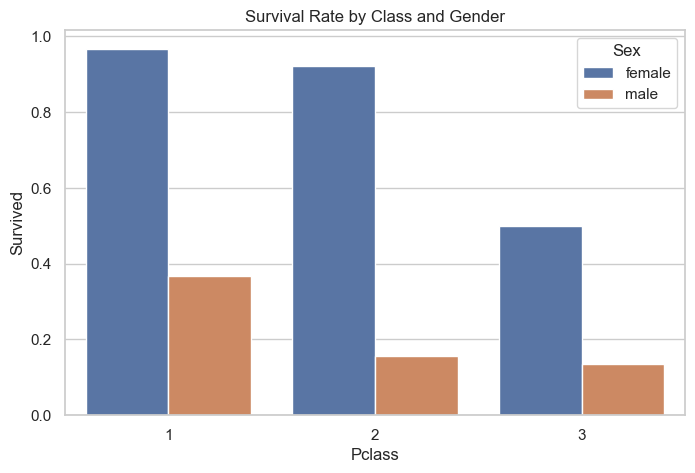

In [80]:
plt.figure(figsize=(8, 5))
survival_data = df.groupby(['Pclass', 'Sex'])['Survived'].mean().reset_index()
sns.barplot(data=survival_data, x='Pclass', y='Survived', hue='Sex')
plt.title('Survival Rate by Class and Gender')
plt.savefig('week2_survival_by_class_and_gender.png', dpi=150)
plt.show()

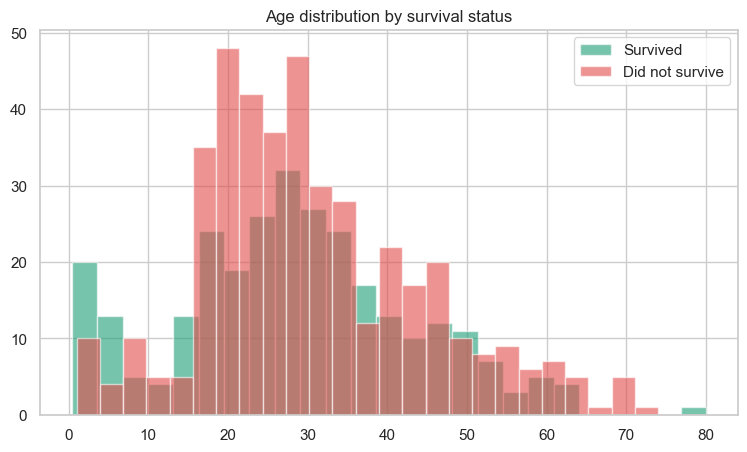

In [81]:
# Chart 2: Overlapping age histograms by survival
plt.figure(figsize=(9, 5))
df[df['Survived']==1]['Age'].hist(bins=25, alpha=0.6, label='Survived', color='#1D9E75')
df[df['Survived']==0]['Age'].hist(bins=25, alpha=0.6, label='Did not survive', color='#E24B4A')
plt.title('Age distribution by survival status')
plt.legend()
plt.savefig('week2_age_distribution_by_survival.png', dpi=150)
plt.show()

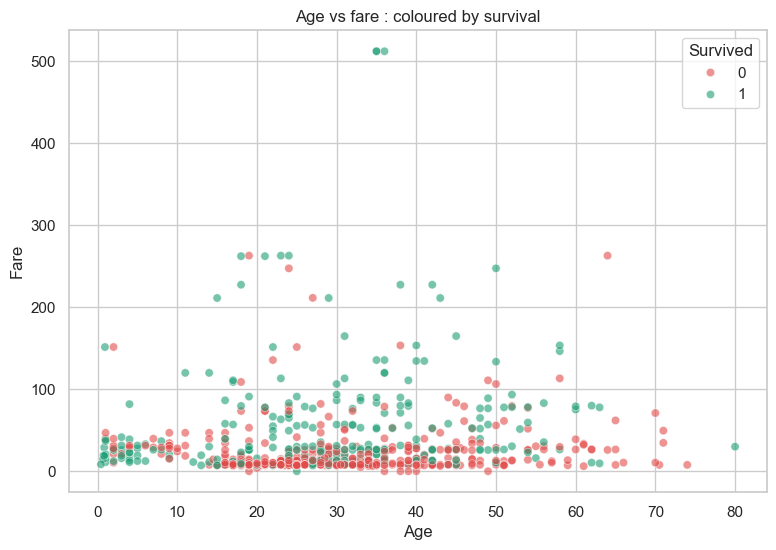

In [82]:
# Chart 3: Age vs fare scatter coloured by survival
plt.figure(figsize=(9, 6))
sns.scatterplot(x='Age', y='Fare', hue='Survived',
                data=df, alpha=0.6, palette={0:'#E24B4A', 1:'#1D9E75'})
plt.title('Age vs fare : coloured by survival')
plt.savefig('week2_age_vs_fare_by_survival.png', dpi=150)
plt.show()

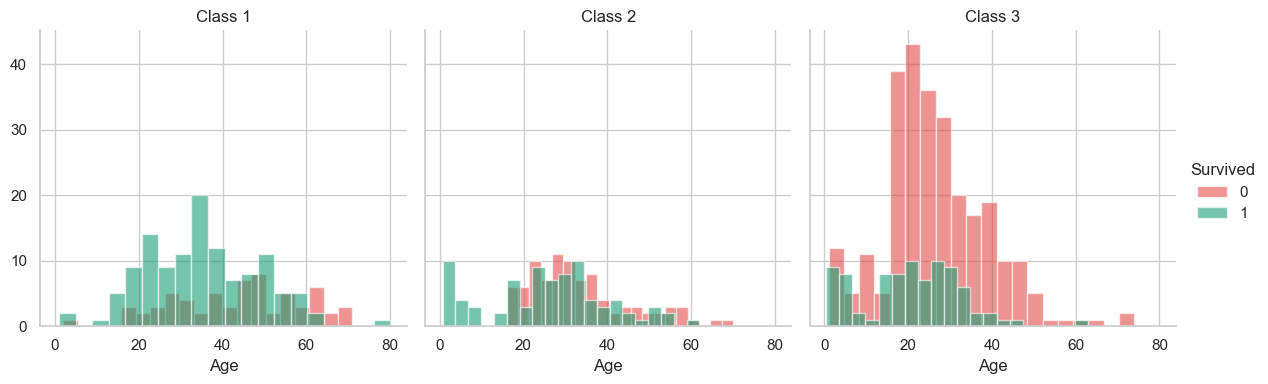

In [83]:
# Chart 4: FacetGrid : age distribution per class
g = sns.FacetGrid(df, col='Pclass', hue='Survived',
                  palette={0:'#E24B4A', 1:'#1D9E75'}, height=4)
g.map(plt.hist, 'Age', bins=20, alpha=0.6)
g.add_legend()
g.set_titles('Class {col_name}')
plt.savefig('week2_age_and_survival_distribution_by_class.png', dpi=150)
plt.show()

0                               Braund, Mr. Owen Harris
1     Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                Heikkinen, Miss. Laina
3          Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                              Allen, Mr. William Henry
                            ...                        
95                          Shorney, Mr. Charles Joseph
96                            Goldschmidt, Mr. George B
97                      Greenfield, Mr. William Bertram
98                 Doling, Mrs. John T (Ada Julia Bone)
99                                    Kantor, Mr. Sinai
Name: Name, Length: 100, dtype: str


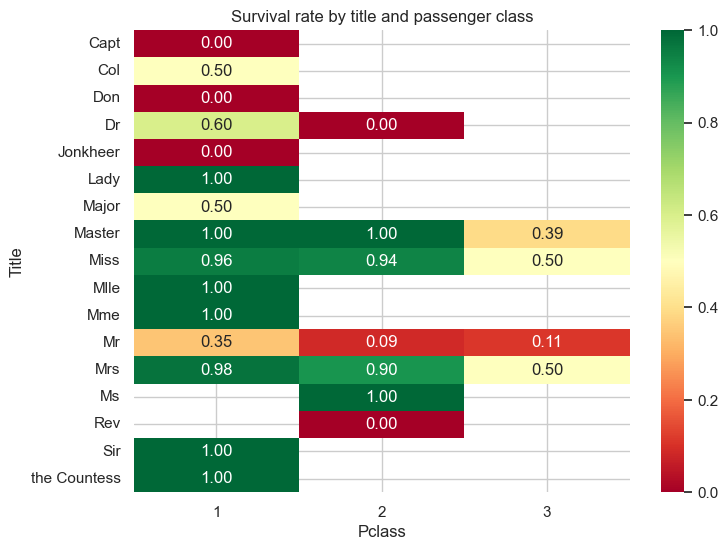

In [ ]:
# Chart 5: Heatmap : survival rate by title and class
df['Title'] = df['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())
title_class = df.groupby(['Title', 'Pclass'])['Survived'].mean().unstack()
plt.figure(figsize=(8, 6))
sns.heatmap(title_class, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1)
plt.title('Survival rate by title and passenger class')
plt.savefig('week2_survival_rate_by_title_and_class.png', dpi=150)
plt.show()